
# Heart Disease Prediction Project   



## Problem Statement

Task 1: Perform complete data analysis.  
Task 2: Build Machine Learning models to predict heart disease.  
Task 3: Provide suggestions to hospital for prevention.

Target Variable:
- 0 → No Heart Disease  
- 1 → Heart Disease Present


## Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

In [6]:

values = pd.read_csv("values.csv")   
labels = pd.read_csv("labels.csv")

# Merge datasets
df = pd.merge(values, labels,on="patient_id")  #(joining(on)the two datasets.)

df.head()


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


## Data Information

In [23]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    int64  
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [24]:
df.describe()

,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,1.366667,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,0.568247,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,0.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,2.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


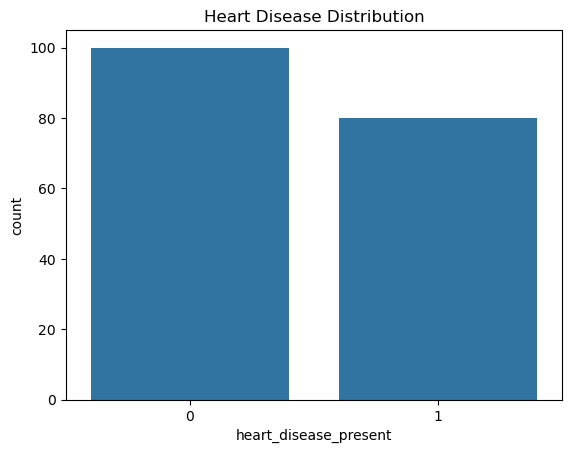

In [14]:
plt.figure()
sns.countplot(x='heart_disease_present', data=df)
plt.title("Heart Disease Distribution")
plt.show()

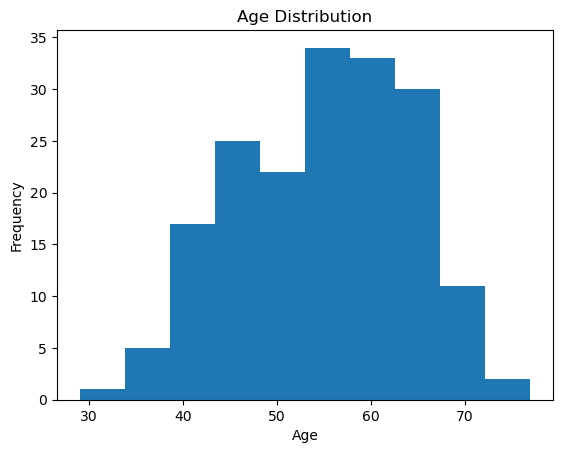

In [35]:
plt.figure()
plt.hist(df['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

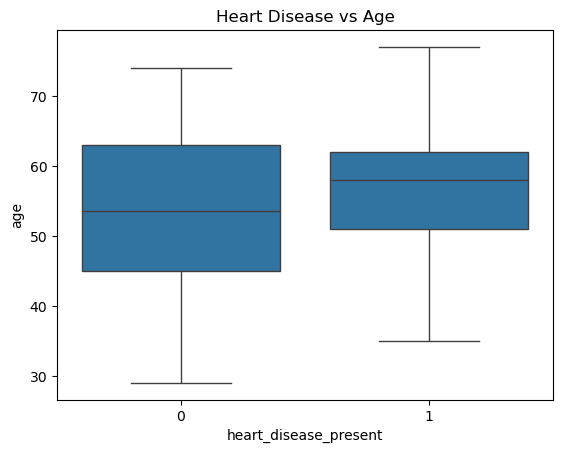

In [22]:
plt.figure()
sns.boxplot(x='heart_disease_present', y='age', data=df)
plt.title("Heart Disease vs Age")
plt.show()

## Encoding Categorical Variable (thal) ((converting text data into numerical values))

In [19]:

le = LabelEncoder()
df['thal'] = le.fit_transform(df['thal'])


## Feature and Target Split

In [9]:

X = df.drop(["heart_disease_present","patient_id"], axis=1)  # input
y = df["heart_disease_present"]     # prediction

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Logistic Regression Model

In [10]:

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.8055555555555556
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.88      0.75      0.81        20

    accuracy                           0.81        36
   macro avg       0.81      0.81      0.81        36
weighted avg       0.82      0.81      0.81        36



## Decision Tree Model

In [11]:

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7777777777777778
              precision    recall  f1-score   support

           0       0.67      1.00      0.80        16
           1       1.00      0.60      0.75        20

    accuracy                           0.78        36
   macro avg       0.83      0.80      0.78        36
weighted avg       0.85      0.78      0.77        36



## Random Forest Model

In [12]:

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8055555555555556
              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36



## Feature Importance  (useful for making predictions)

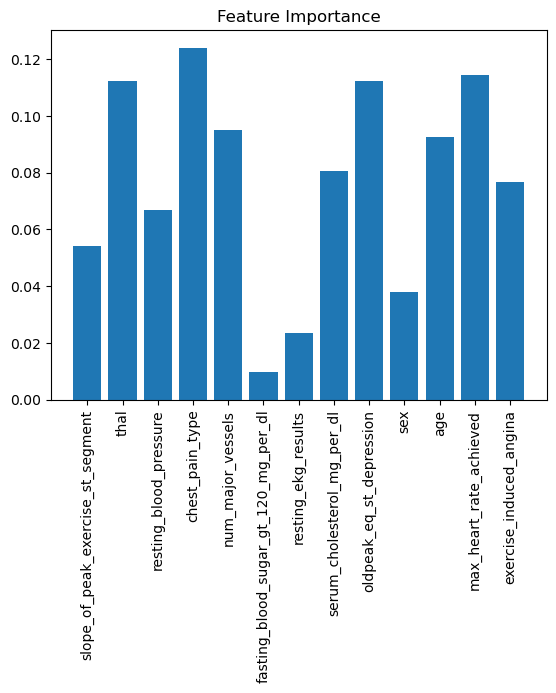

In [33]:
importances = rf_model.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

## Model Comparison

In [13]:

print("Logistic:", accuracy_score(y_test, y_pred_log))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))


Logistic: 0.8055555555555556
Decision Tree: 0.7777777777777778
Random Forest: 0.8055555555555556



## Suggestions to Hospital

1. Regular heart checkups for patients above 40 years.  
2. Encourage exercise and healthy lifestyle.  
3. Use Machine Learning model for early risk detection.



## Challenges Faced

1. Handling categorical variable (thal) → solved using Label Encoding.
2. Avoiding overfitting → used Random Forest for better generalization.



## Conclusion

These are the 3 models 

- Logistic Regression  
- Decision Tree  
- Random Forest  

Random Forest generally performs better because it reduces overfitting.
